# Exploratory Data Analysis (EDA) - Don't Patronize Me Dataset

In [73]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.chunk import ne_chunk
from nltk.util import ngrams
from wordcloud import WordCloud
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('words', quiet=True)
    
# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Set base directory
BASE_DIR = Path('../data/raw')

## Data Loading

Load the main dataset and train/dev splits.

In [74]:
# Load main dataset
df = pd.read_csv(
    BASE_DIR / 'dontpatronizeme_pcl.tsv',
    sep='\t',
    skiprows=4,  # Skip disclaimer
    names=['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label']
)

# Convert labels from 0-4 scale to binary classification
# {0,1} = No PCL, {2,3,4} = PCL
df['label_binary'] = df['label'].apply(lambda x: 0 if x in [0, 1] else 1)

print(f"Loaded {len(df)} examples")
print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution (original 0-4 scale):")
print(df['label'].value_counts().sort_index())
print(f"\nLabel distribution (binary):")
print(df['label_binary'].value_counts())
print(f"\nFirst few rows:")
df.head()

Loaded 10469 examples

Dataset shape: (10469, 7)

Columns: ['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label', 'label_binary']

Label distribution (original 0-4 scale):
label
0    8529
1     947
2     144
3     458
4     391
Name: count, dtype: int64

Label distribution (binary):
label_binary
0    9476
1     993
Name: count, dtype: int64

First few rows:


,par_id,art_id,keyword,country_code,text,label,label_binary
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0,0


In [75]:
# Load train/dev splits
train_ids = pd.read_csv(BASE_DIR / 'train_semeval_parids-labels.csv')
dev_ids = pd.read_csv(BASE_DIR / 'dev_semeval_parids-labels.csv')

# Use only the par_id column to split
train_id_set = set(train_ids['par_id'])
dev_id_set = set(dev_ids['par_id'])

train_df = df[df['par_id'].isin(train_id_set)].copy()
dev_df = df[df['par_id'].isin(dev_id_set)].copy()

print(f"Train set: {len(train_df)} examples")
print(f"Dev set: {len(dev_df)} examples")
print(f"\nTrain set class distribution:")
print(train_df['label_binary'].value_counts())
print(f"\nDev set class distribution:")
print(dev_df['label_binary'].value_counts())

Train set: 8375 examples
Dev set: 2094 examples

Train set class distribution:
label_binary
0    7581
1     794
Name: count, dtype: int64

Dev set class distribution:
label_binary
0    1895
1     199
Name: count, dtype: int64


## 1.1 Basic Statistical Profiling

In [76]:
# Calculate text statistics
train_df['word_count'] = train_df['text'].str.split().str.len()

# Tokenize for token counting
def count_tokens(text):
    try:
        return len(word_tokenize(str(text)))
    except:
        return len(str(text).split())

train_df['token_count'] = train_df['text'].apply(count_tokens)

# Statistics by class
stats_by_class = train_df.groupby('label_binary').agg({
    'word_count': ['mean', 'median', 'min', 'max', 'std'],
    'token_count': ['mean', 'median', 'min', 'max', 'std']
}).round(2)

print("Text Statistics by Class (Binary: 0=No PCL, 1=PCL):")
print("=" * 80)
print(stats_by_class)

Text Statistics by Class (Binary: 0=No PCL, 1=PCL):
             word_count                        token_count                  \
                   mean median min  max    std        mean median min  max   
label_binary                                                                 
0                 48.17   42.0   1  909  29.18       48.17   42.0   1  909   
1                 53.52   47.0   6  512  33.67       53.52   47.0   6  512   

                     
                std  
label_binary         
0             29.18  
1             33.67  


Class Distribution:
No PCL (0): 6,825 examples (81.49%)
PCL (1): 756 examples (9.03%)
Imbalance Ratio: 9.03:1

Multiclass Distribution (0-4):
Class 0: 6,825 examples (81.49%)
Class 1: 756 examples (9.03%)
Class 2: 126 examples (1.50%)
Class 3: 369 examples (4.41%)
Class 4: 299 examples (3.57%)


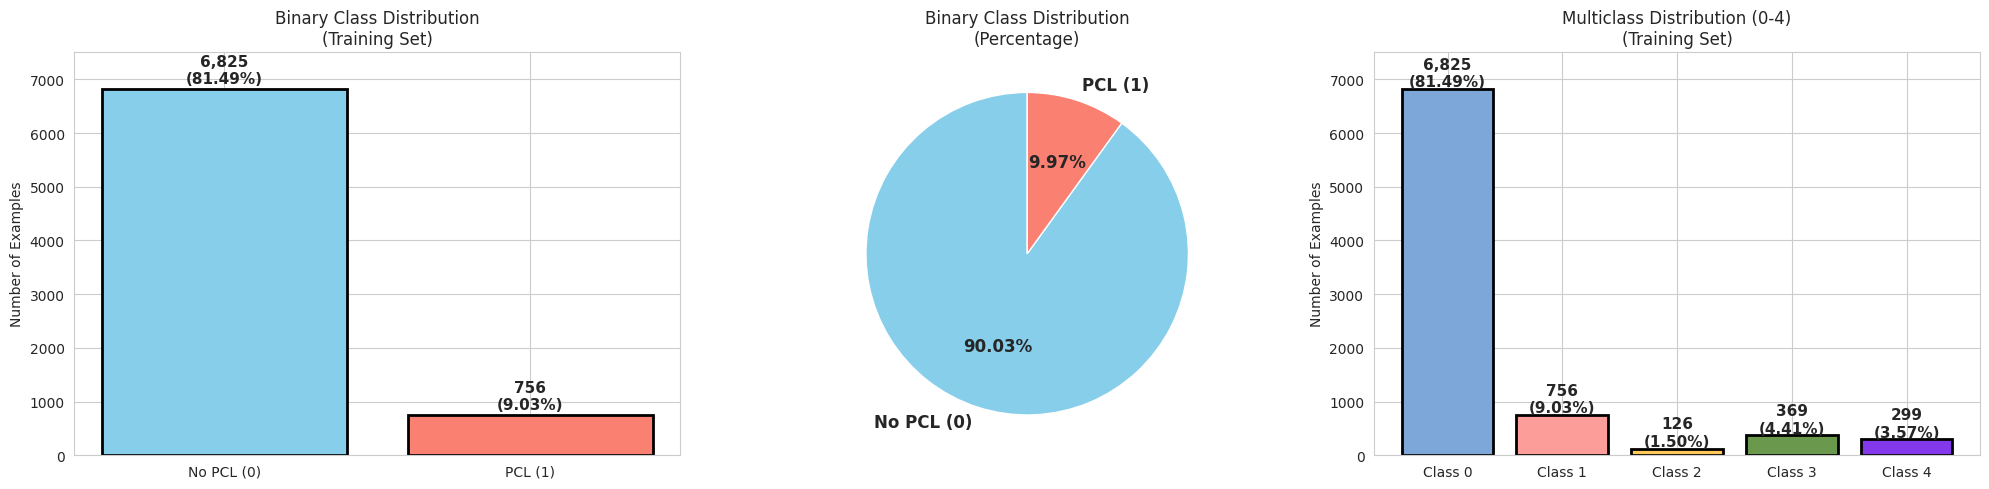

In [89]:
# Class distribution analysis (binary: 0 or 1, multiclass: 0-4)
class_dist = train_df['label'].value_counts()
class_pct = train_df['label'].value_counts(normalize=True) * 100

print("Class Distribution:")
print("=" * 50)
print(f"No PCL (0): {class_dist[0]:,} examples ({class_pct[0]:.2f}%)")
print(f"PCL (1): {class_dist[1]:,} examples ({class_pct[1]:.2f}%)")
print(f"Imbalance Ratio: {class_dist[0]/class_dist[1]:.2f}:1")

# Multiclass distribution (for classes 0-4)
multiclass_dist = train_df['label'].value_counts().reindex([0,1,2,3,4], fill_value=0)
multiclass_pct = train_df['label'].value_counts(normalize=True).reindex([0,1,2,3,4], fill_value=0) * 100

print("\nMulticlass Distribution (0-4):")
for c in [0,1,2,3,4]:
    print(f"Class {c}: {multiclass_dist[c]:,} examples ({multiclass_pct[c]:.2f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Bar chart (binary: 0 vs 1)
axes[0].bar(['No PCL (0)', 'PCL (1)'], [class_dist.get(0,0), class_dist.get(1,0)], 
            color=['skyblue', 'salmon'], edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Examples')
axes[0].set_title('Binary Class Distribution\n(Training Set)')
axes[0].set_ylim(0, max(class_dist.values) * 1.1)
for i, v in enumerate([class_dist.get(0,0), class_dist.get(1,0)]):
    pct = class_pct.get(i, 0)
    axes[0].text(i, v + 100, f'{v:,}\n({pct:.2f}%)', ha='center', fontweight='bold', fontsize=11)

# Pie chart (binary)
axes[1].pie([class_dist.get(0,0), class_dist.get(1,0)], labels=['No PCL (0)', 'PCL (1)'], 
           autopct='%1.2f%%', colors=['skyblue', 'salmon'], 
           startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Binary Class Distribution\n(Percentage)')

# Bar chart (multiclass: 0-4)
multiclass_labels = [f'Class {i}' for i in [0,1,2,3,4]]
multiclass_colors = ['#7da7d9', '#fc9d99', '#ffc857', '#6a994e', '#8338ec']
bars = axes[2].bar(multiclass_labels, multiclass_dist.values, 
                   color=multiclass_colors, edgecolor='black', linewidth=2)
axes[2].set_ylabel('Number of Examples')
axes[2].set_title('Multiclass Distribution (0-4)\n(Training Set)')
axes[2].set_ylim(0, max(multiclass_dist.values) * 1.1)
for i, v in enumerate(multiclass_dist.values):
    axes[2].text(i, v + 50, f'{v:,}\n({multiclass_pct.iloc[i]:.2f}%)', 
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../output/technique1_class_distribution_with_multiclass.png', dpi=300, bbox_inches='tight')
plt.show()

Vocabulary Analysis:
Total unique vocabulary: 29,540 words
No PCL vocabulary: 26,475 words
PCL vocabulary: 6,963 words
Overlapping vocabulary: 5,414 words
Unique to No PCL: 21,061 words
Unique to PCL: 1,549 words


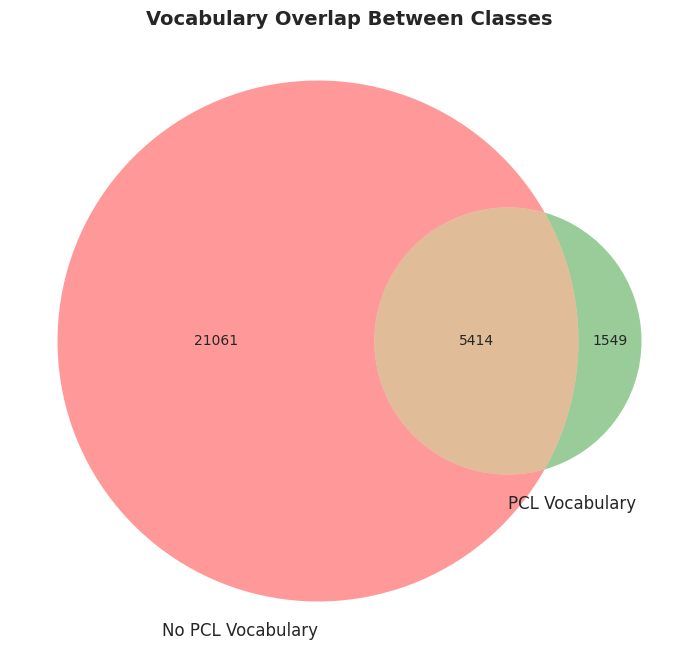

In [78]:
from matplotlib_venn import venn2
# Vocabulary size analysis
def get_vocabulary(text_series):
    """Extract unique vocabulary from text series"""
    all_words = []
    for text in text_series:
        try:
            tokens = word_tokenize(str(text).lower())
            all_words.extend(tokens)
        except:
            words = str(text).lower().split()
            all_words.extend(words)
    return set(all_words)

vocab_no_pcl = get_vocabulary(train_df[train_df['label']==0]['text'])
vocab_pcl = get_vocabulary(train_df[train_df['label']==1]['text'])
vocab_all = get_vocabulary(train_df['text'])

vocab_overlap = len(vocab_no_pcl & vocab_pcl)
vocab_unique_no_pcl = len(vocab_no_pcl - vocab_pcl)
vocab_unique_pcl = len(vocab_pcl - vocab_no_pcl)

print("Vocabulary Analysis:")
print("=" * 50)
print(f"Total unique vocabulary: {len(vocab_all):,} words")
print(f"No PCL vocabulary: {len(vocab_no_pcl):,} words")
print(f"PCL vocabulary: {len(vocab_pcl):,} words")
print(f"Overlapping vocabulary: {vocab_overlap:,} words")
print(f"Unique to No PCL: {vocab_unique_no_pcl:,} words")
print(f"Unique to PCL: {vocab_unique_pcl:,} words")

# Visualize vocabulary overlap
fig, ax = plt.subplots(figsize=(10, 8))
venn2([vocab_no_pcl, vocab_pcl], 
        set_labels=('No PCL Vocabulary', 'PCL Vocabulary'),
        ax=ax)
ax.set_title('Vocabulary Overlap Between Classes', fontsize=14, fontweight='bold')
plt.savefig('../output/technique1_vocabulary_overlap.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.2 Lexical Analysis: Word Frequencies and N-grams

In [79]:
# Word frequency analysis
def get_word_frequencies(text_series, top_n=30):
    """Get top N most frequent words"""
    all_words = []
    for text in text_series:
        try:
            tokens = word_tokenize(str(text).lower())
            # Remove punctuation and keep only alphabetic words
            tokens = [t for t in tokens if t.isalpha()]
            all_words.extend(tokens)
        except:
            words = str(text).lower().split()
            words = [w for w in words if w.isalpha()]
            all_words.extend(words)
    return Counter(all_words).most_common(top_n)

# Get stopwords
try:
    stop_words = set(stopwords.words('english'))
except:
    stop_words = set(['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by'])

# Word frequencies by class
freq_no_pcl = get_word_frequencies(train_df[train_df['label']==0]['text'], top_n=30)
freq_pcl = get_word_frequencies(train_df[train_df['label']==1]['text'], top_n=30)

# Calculate relative frequencies
def get_relative_freq(word_freq_list, total_words):
    return {word: count/total_words for word, count in word_freq_list}

total_no_pcl = sum([count for _, count in freq_no_pcl])
total_pcl = sum([count for _, count in freq_pcl])

rel_freq_no_pcl = get_relative_freq(freq_no_pcl, total_no_pcl)
rel_freq_pcl = get_relative_freq(freq_pcl, total_pcl)

# Find words more common in PCL
pcl_indicative = {}
freq_pcl_dict = dict(freq_pcl)
for word, freq in rel_freq_pcl.items():
    if word in rel_freq_no_pcl:
        ratio = freq / rel_freq_no_pcl[word] if rel_freq_no_pcl[word] > 0 else float('inf')
        if ratio > 1.5:  # At least 1.5x more frequent
            # Get count from freq_pcl list
            pcl_count = next((count for w, count in freq_pcl if w == word), 0)
            pcl_indicative[word] = (ratio, pcl_count)

print("Top 30 Most Frequent Words - No PCL:")
print("=" * 50)
for word, count in freq_no_pcl:
    print(f"{word:20s} {count:6,}")

print("\nTop 30 Most Frequent Words - PCL:")
print("=" * 50)
for word, count in freq_pcl:
    print(f"{word:20s} {count:6,}")

print("\nWords More Frequent in PCL (at least 1.5x):")
print("=" * 50)
sorted_pcl = sorted(pcl_indicative.items(), key=lambda x: x[1][0], reverse=True)[:20]
for word, (ratio, count) in sorted_pcl:
    print(f"{word:20s} {ratio:.2f}x more frequent (appears {count} times)")

Top 30 Most Frequent *Non-Stopword* Words - No PCL:
said                  1,382
people                1,073
women                 1,070
immigrants              946
vulnerable              824
families                758
need                    744
disabled                737
also                    660
poor                    633
refugees                627
one                     600
new                     563
homeless                558
children                541
government              534
would                   511
many                    497
country                 470
us                      396
year                    374
refugee                 355
illegal                 345
migrants                335
immigrant               332
years                   331
two                     330
hopeless                315
like                    313
could                   305

Top 30 Most Frequent *Non-Stopword* Words - PCL:
people                  213
said                    211
fa

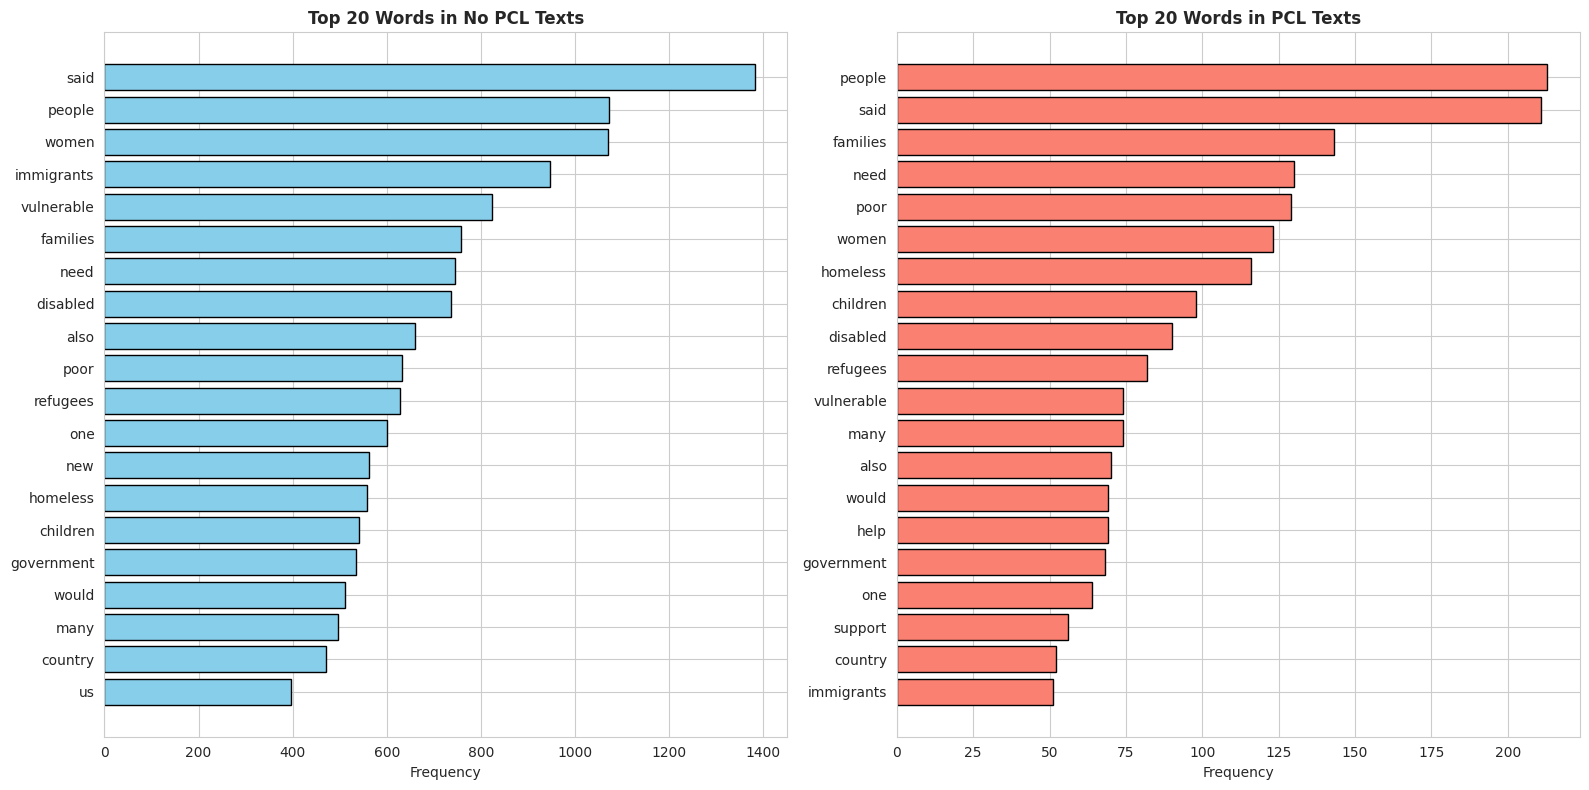

In [ ]:
# Visualize top words comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top words in No PCL
words_no_pcl = [w[0] for w in freq_no_pcl[:20]]
counts_no_pcl = [w[1] for w in freq_no_pcl[:20]]
axes[0].barh(range(len(words_no_pcl)), counts_no_pcl, color='skyblue', edgecolor='black')
axes[0].set_yticks(range(len(words_no_pcl)))
axes[0].set_yticklabels(words_no_pcl)
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 20 Words in No PCL Texts', fontweight='bold')
axes[0].invert_yaxis()

# Top words in PCL
words_pcl = [w[0] for w in freq_pcl[:20]]
counts_pcl = [w[1] for w in freq_pcl[:20]]
axes[1].barh(range(len(words_pcl)), counts_pcl, color='salmon', edgecolor='black')
axes[1].set_yticks(range(len(words_pcl)))
axes[1].set_yticklabels(words_pcl)
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 20 Words in PCL Texts', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../output/technique1_word_frequencies.png', dpi=300, bbox_inches='tight')
plt.show()

Top 20 Bigrams - No PCL:
poor families                               512
illegal immigrants                          233
per cent                                    129
united states                               116
last year                                    90
sri lanka                                    77
disabled people                              76
new york                                     76
hong kong                                    69
human rights                                 68
homeless people                              67
men women                                    65
donald trump                                 64
migrant workers                              59
people need                                  54
new zealand                                  54
million people                               52
years ago                                    48
undocumented immigrants                      47
united nations                               45

Top 20 Bigrams

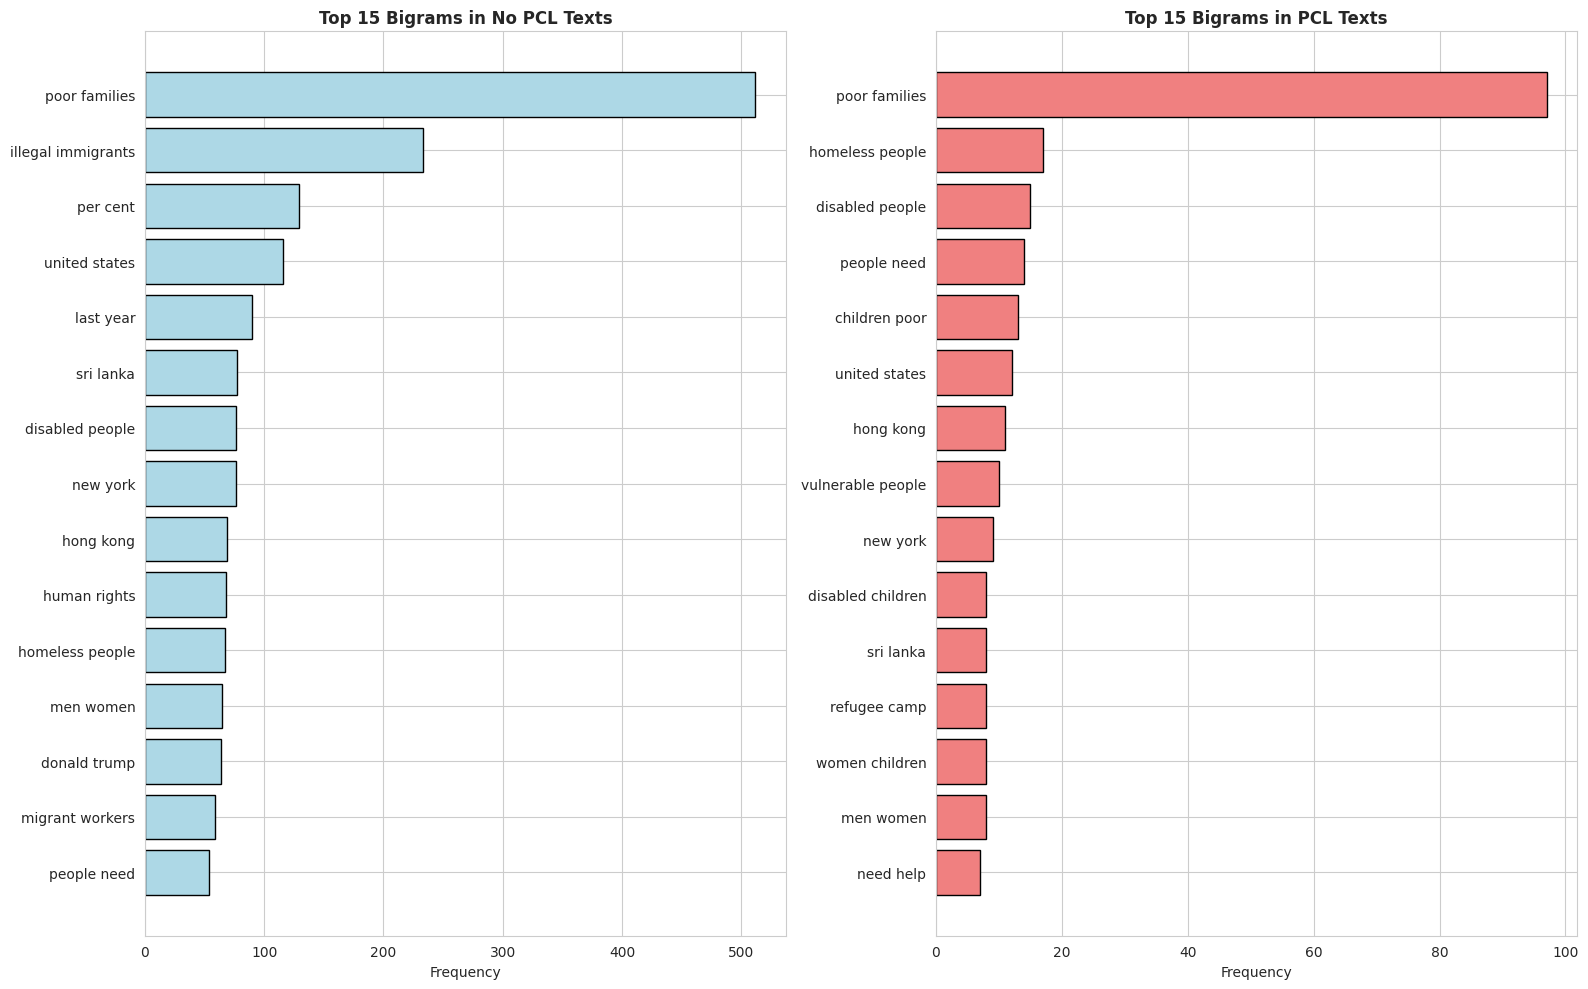

In [81]:
# N-gram analysis (Bigrams and Trigrams)
def get_ngrams(text_series, n=2, top_n=20):
    """Extract top N n-grams"""
    all_ngrams = []
    for text in text_series:
        try:
            tokens = word_tokenize(str(text).lower())
            tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
            ngram_list = list(ngrams(tokens, n))
            all_ngrams.extend(ngram_list)
        except:
            words = str(text).lower().split()
            words = [w for w in words if w.isalpha() and w not in stop_words]
            ngram_list = list(ngrams(words, n))
            all_ngrams.extend(ngram_list)
    return Counter(all_ngrams).most_common(top_n)

# Bigrams
bigrams_no_pcl = get_ngrams(train_df[train_df['label']==0]['text'], n=2, top_n=20)
bigrams_pcl = get_ngrams(train_df[train_df['label']==1]['text'], n=2, top_n=20)

print("Top 20 Bigrams - No PCL:")
print("=" * 60)
for ngram, count in bigrams_no_pcl:
    print(f"{' '.join(ngram):40s} {count:6,}")

print("\nTop 20 Bigrams - PCL:")
print("=" * 60)
for ngram, count in bigrams_pcl:
    print(f"{' '.join(ngram):40s} {count:6,}")

# Visualize top bigrams
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# No PCL bigrams
bigram_texts_no_pcl = [' '.join(b[0]) for b in bigrams_no_pcl[:15]]
bigram_counts_no_pcl = [b[1] for b in bigrams_no_pcl[:15]]
axes[0].barh(range(len(bigram_texts_no_pcl)), bigram_counts_no_pcl, color='lightblue', edgecolor='black')
axes[0].set_yticks(range(len(bigram_texts_no_pcl)))
axes[0].set_yticklabels(bigram_texts_no_pcl)
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 15 Bigrams in No PCL Texts', fontweight='bold')
axes[0].invert_yaxis()

# PCL bigrams
bigram_texts_pcl = [' '.join(b[0]) for b in bigrams_pcl[:15]]
bigram_counts_pcl = [b[1] for b in bigrams_pcl[:15]]
axes[1].barh(range(len(bigram_texts_pcl)), bigram_counts_pcl, color='lightcoral', edgecolor='black')
axes[1].set_yticks(range(len(bigram_texts_pcl)))
axes[1].set_yticklabels(bigram_texts_pcl)
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 15 Bigrams in PCL Texts', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../output/technique1_bigrams.png', dpi=300, bbox_inches='tight')
plt.show()

Stop Word Density Analysis:
No PCL - Mean: 0.423, Median: 0.426
PCL - Mean: 0.448, Median: 0.450


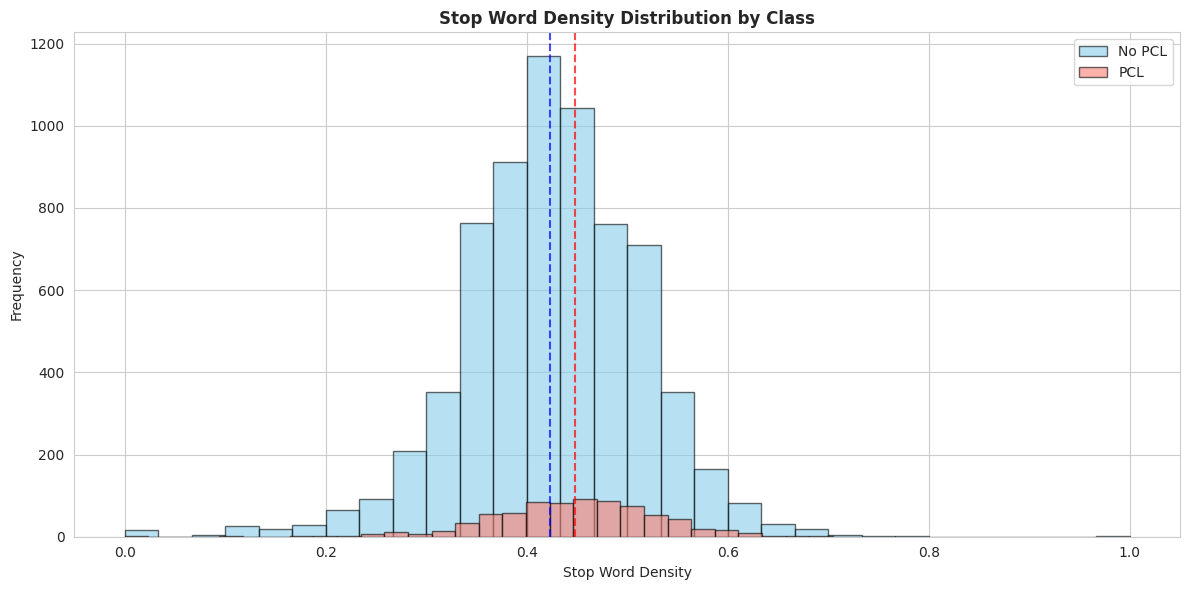

In [82]:
# Stop word density analysis
def calculate_stopword_density(text_series):
    """Calculate stop word density"""
    densities = []
    for text in text_series:
        try:
            tokens = word_tokenize(str(text).lower())
            tokens = [t for t in tokens if t.isalpha()]
            if len(tokens) > 0:
                stopword_count = sum(1 for t in tokens if t in stop_words)
                density = stopword_count / len(tokens)
                densities.append(density)
        except:
            words = str(text).lower().split()
            words = [w for w in words if w.isalpha()]
            if len(words) > 0:
                stopword_count = sum(1 for w in words if w in stop_words)
                density = stopword_count / len(words)
                densities.append(density)
    return np.array(densities)

stopword_density_no_pcl = calculate_stopword_density(train_df[train_df['label']==0]['text'])
stopword_density_pcl = calculate_stopword_density(train_df[train_df['label']==1]['text'])

print("Stop Word Density Analysis:")
print("=" * 50)
print(f"No PCL - Mean: {stopword_density_no_pcl.mean():.3f}, Median: {np.median(stopword_density_no_pcl):.3f}")
print(f"PCL - Mean: {stopword_density_pcl.mean():.3f}, Median: {np.median(stopword_density_pcl):.3f}")

# Visualize stop word density
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(stopword_density_no_pcl, bins=30, alpha=0.6, label='No PCL', color='skyblue', edgecolor='black')
ax.hist(stopword_density_pcl, bins=30, alpha=0.6, label='PCL', color='salmon', edgecolor='black')
ax.set_xlabel('Stop Word Density')
ax.set_ylabel('Frequency')
ax.set_title('Stop Word Density Distribution by Class', fontweight='bold')
ax.legend()
ax.axvline(stopword_density_no_pcl.mean(), color='blue', linestyle='--', alpha=0.7)
ax.axvline(stopword_density_pcl.mean(), color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../output/technique1_stopword_density.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.3 Part-of-Speech (POS) Tagging Analysis

Modal Verb Usage:
No PCL - Mean: 0.42, Median: 0.00
PCL - Mean: 0.53, Median: 0.00

Pronoun Usage:
No PCL - Mean: 0.79, Median: 0.00
PCL - Mean: 1.17, Median: 1.00


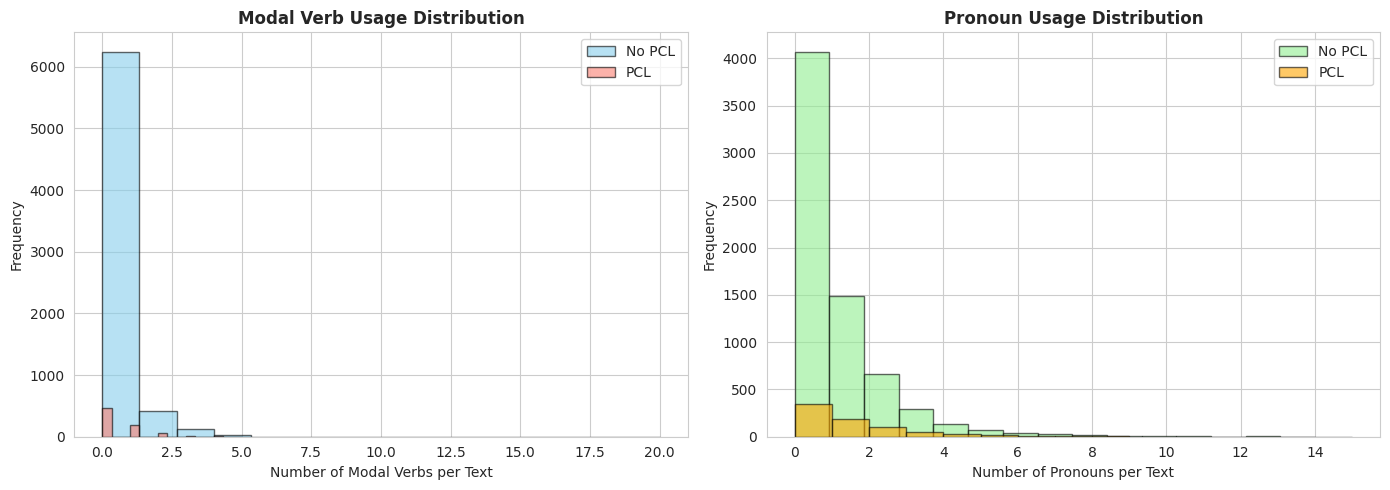

In [83]:
# Analyze specific POS patterns in PCL vs No PCL
# Look at modal verbs, adjectives, and pronouns which might indicate patronizing language
modal_verbs = ['can', 'could', 'should', 'would', 'must', 'may', 'might', 'will', 'shall']
pronouns = ['they', 'them', 'their', 'we', 'us', 'our', 'you', 'your']

def count_pattern_words(text_series, pattern_words):
    """Count occurrences of pattern words"""
    counts = []
    for text in text_series:
        try:
            tokens = word_tokenize(str(text).lower())
            count = sum(1 for t in tokens if t in pattern_words)
            counts.append(count)
        except:
            words = str(text).lower().split()
            count = sum(1 for w in words if w in pattern_words)
            counts.append(count)
    return np.array(counts)

modal_no_pcl = count_pattern_words(train_df[train_df['label']==0]['text'], modal_verbs)
modal_pcl = count_pattern_words(train_df[train_df['label']==1]['text'], modal_verbs)
pronoun_no_pcl = count_pattern_words(train_df[train_df['label']==0]['text'], pronouns)
pronoun_pcl = count_pattern_words(train_df[train_df['label']==1]['text'], pronouns)

print("Modal Verb Usage:")
print("=" * 50)
print(f"No PCL - Mean: {modal_no_pcl.mean():.2f}, Median: {np.median(modal_no_pcl):.2f}")
print(f"PCL - Mean: {modal_pcl.mean():.2f}, Median: {np.median(modal_pcl):.2f}")

print("\nPronoun Usage:")
print("=" * 50)
print(f"No PCL - Mean: {pronoun_no_pcl.mean():.2f}, Median: {np.median(pronoun_no_pcl):.2f}")
print(f"PCL - Mean: {pronoun_pcl.mean():.2f}, Median: {np.median(pronoun_pcl):.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(modal_no_pcl, bins=15, alpha=0.6, label='No PCL', color='skyblue', edgecolor='black')
axes[0].hist(modal_pcl, bins=15, alpha=0.6, label='PCL', color='salmon', edgecolor='black')
axes[0].set_xlabel('Number of Modal Verbs per Text')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Modal Verb Usage Distribution', fontweight='bold')
axes[0].legend()

axes[1].hist(pronoun_no_pcl, bins=15, alpha=0.6, label='No PCL', color='lightgreen', edgecolor='black')
axes[1].hist(pronoun_pcl, bins=15, alpha=0.6, label='PCL', color='orange', edgecolor='black')
axes[1].set_xlabel('Number of Pronouns per Text')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Pronoun Usage Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/technique2_linguistic_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

---

# Identifying Noise and Artifacts

In [ ]:
# Check for texts appearing in both training and testing sets
common_texts = set(train_df['text']).intersection(set(dev_df['text']))
print("Train/Test Overlap Analysis:")
print("=" * 50)
print(f"Number of texts appearing in both train and test sets: {len(common_texts)}")

if len(common_texts) > 0:
    print("\nSample overlapping texts:")
    for i, txt in enumerate(list(common_texts)[:3]):
        print(f"\nText {i+1}: {txt[:100]}...")

# Check for empty or very short texts in train_df
empty_texts = train_df[train_df['text'].str.strip().str.len() == 0]
very_short = train_df[train_df['text'].str.strip().str.len() < 10]
print(f"\nEmpty texts in train: {len(empty_texts)}")
print(f"Very short texts (<10 chars) in train: {len(very_short)}")

# Check for empty or very short texts in dev_df
empty_texts_test = dev_df[dev_df['text'].str.strip().str.len() == 0]
very_short_test = dev_df[dev_df['text'].str.strip().str.len() < 10]
print(f"Empty texts in test: {len(empty_texts_test)}")
print(f"Very short texts (<10 chars) in test: {len(very_short_test)}")

Train/Test Overlap Analysis:
Number of texts appearing in both train and test sets: 0

Empty texts in train: 0
Very short texts (<10 chars) in train: 1
Empty texts in test: 0
Very short texts (<10 chars) in test: 0


In [85]:
# Check for HTML tags and special characters
html_pattern = r'<[^>]+>'
html_tags = train_df[train_df['text'].str.contains(html_pattern, regex=True, na=False)]
urls = train_df[train_df['text'].str.contains(r'http[s]?://', regex=True, na=False)]
special_chars = train_df[train_df['text'].str.contains(r'[^\x00-\x7F]', regex=True, na=False)]

print("Special Character and HTML Analysis:")
print("=" * 50)
print(f"Texts with HTML tags: {len(html_tags)} ({len(html_tags)/len(train_df)*100:.2f}%)")
print(f"Texts with URLs: {len(urls)} ({len(urls)/len(train_df)*100:.2f}%)")
print(f"Texts with non-ASCII characters: {len(special_chars)} ({len(special_chars)/len(train_df)*100:.2f}%)")

if len(html_tags) > 0:
    print("\nSample texts with HTML tags:")
    for idx, row in html_tags.head(3).iterrows():
        print(f"\nID {row['par_id']}: {row['text'][:150]}...")

Special Character and HTML Analysis:
Texts with HTML tags: 316 (3.77%)
Texts with URLs: 0 (0.00%)
Texts with non-ASCII characters: 0 (0.00%)

Sample texts with HTML tags:

ID 16: Apart from Pakistan and hosts England , Bangladesh disabled cricket team will also participate in the tournament . <h> Shahid Afridi bags 11 Man of th...

ID 38: Rizvi : There will be no joy this Eid <h> ' The citizens of this nation are becoming hopeless '...

ID 55: Over the past 15 years , the show has handed over more than $50 million to the Mustard Seed Communities to assist with the care of more than 400 aband...


Outlier Analysis (using IQR method, token_count):
Lower bound: -15 tokens
Upper bound: 105 tokens
Outliers: 371 (4.43%)


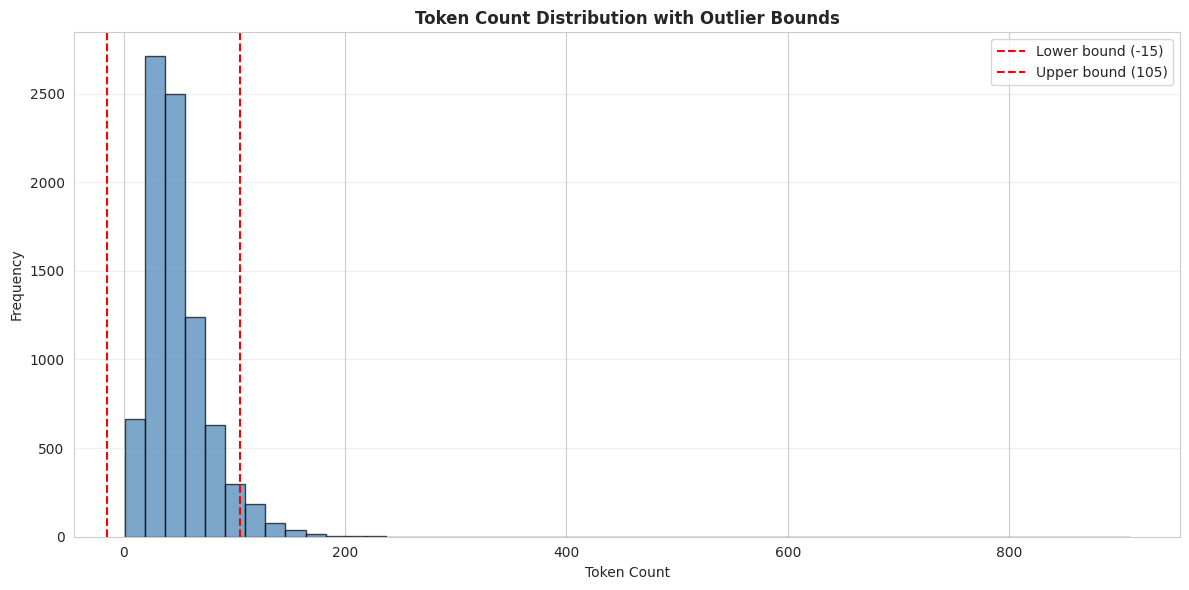


Shortest texts (potential outliers by token_count):
      par_id  token_count                      text
1656    1657            1                  refugees
317      318            3    The Filipino immigrant
1954    1955            3        Review refugee law
3120    3121            3  *Fighting over men/women
6020    6021            3      Pretty much hopeless

Longest texts (potential outliers by token_count):
      par_id  token_count                                               text
7418    7419          909  Dr Mayengbam Lalit Singh Recently honourable P...
6832    6833          512  Most are from desperately poor Horn of Africa ...
5977    5978          419  Mahinda Wijesinghe , the Inspector General of ...
8191    8192          390  ANNUAL State of Education Report ( ASER ) laun...
292      293          266  The following is a brief history of the Rajnee...


In [ ]:
# Outlier analysis: extremely long or short texts (by token_count)
Q1 = train_df['token_count'].quantile(0.25)
Q3 = train_df['token_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_df[(train_df['token_count'] < lower_bound) | (train_df['token_count'] > upper_bound)]

print("Outlier Analysis (using IQR method, token_count):")
print("=" * 50)
print(f"Lower bound: {lower_bound:.0f} tokens")
print(f"Upper bound: {upper_bound:.0f} tokens")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(train_df)*100:.2f}%)")

# Visualize token count distribution with outliers marked
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(train_df['token_count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(lower_bound, color='red', linestyle='--', label=f'Lower bound ({lower_bound:.0f})')
ax.axvline(upper_bound, color='red', linestyle='--', label=f'Upper bound ({upper_bound:.0f})')
ax.set_xlabel('Token Count')
ax.set_ylabel('Frequency')
ax.set_title('Token Count Distribution with Outlier Bounds', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../output/noise_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nShortest texts (potential outliers by token_count):")
print(train_df.nsmallest(5, 'token_count')[['par_id', 'token_count', 'text']])
print(f"\nLongest texts (potential outliers by token_count):")
print(train_df.nlargest(5, 'token_count')[['par_id', 'token_count', 'text']])